In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 훈련 셋과 테스트 셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.layers import LeakyReLU, ELU, ReLU
from matplotlib import pyplot as plt # 학습과정 시각화
# scale 조정, train_test_split 등을 추가

In [3]:
# mnist 데이터를 plt,imshow하기
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_test.shape, y_test.shape

((10000, 28, 28), (10000,))

In [4]:
y_test[:30]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6,
       6, 5, 4, 0, 7, 4, 0, 1], dtype=uint8)

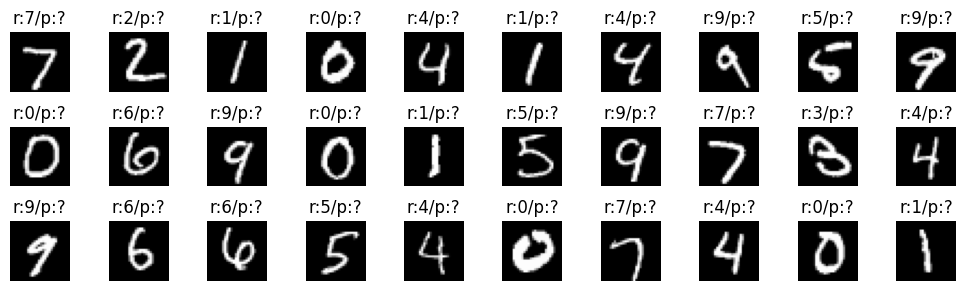

In [21]:
plt_row = 3
plt_col = 10
# plt.figure(figsize=(plt_col,plt_row))
plt.rcParams['figure.figsize'] = (plt_col,plt_row)
fig, axarr = plt.subplots(nrows=plt_row, ncols=plt_col)
# plt.subplots_adjust(hspace=0.4, wspace=0.3)
# axarr[1,1].imshow(X_test[11], cmap ='gray')
# axarr[1,1].axis('off')
# axarr[1,1].set_title(f'real : {y_test[11]}')

for i in range(plt_row*plt_col):
    ax=axarr[i//plt_col, i%plt_col]
    ax.imshow(X_test[i], cmap ='gray')
    ax.axis('off')
    ax.set_title(f'r:{y_test[i]}/p:?')
plt.tight_layout()

# 1. DNN

In [22]:
%%time
(X_train, y_train), (X_test,y_test) = mnist.load_data()

X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

train_X = X_train.reshape(50000,28*28).astype('float32')/255.0
val_X = X_val.reshape(-1,784).astype('float32')/255.0
test_X = X_test.reshape(10000,-1).astype('float32')/255.0

train_Y = to_categorical(y_train, 10) # 10:카테고리수(안쓰면 자동 입력)
val_Y = to_categorical(y_val)
test_Y= to_categorical(y_test)

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=512)) # activation = 'leakeyrelu' 사용 불가
model.add(LeakyReLU(alpha=0.01)) # 음수결과에 대해 1%만 통과
model.add(Dropout(0.2))
model.add(Dense(units=256))
model.add(LeakyReLU(alpha=0.01))
model.add(Dropout(0.3))
model.add(Dense(units=128))
model.add(LeakyReLU(alpha=0.01))
model.add(Dropout(0.3))
model.add(Dense(units=64))
model.add(LeakyReLU(alpha=0.01))
model.add(Dropout(0.3))
model.add(Dense(units=10, activation='softmax'))

model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy(원핫인코딩 자동으로)
              optimizer='adam',
              metrics=['accuracy'] # 평가지표
             )

hist = model.fit(train_X, train_Y, # 학습셋
                epochs=20,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1)

score = model.evaluate(test_X,test_Y)
score[1]

Epoch 1/20
500/500 [==============================] - 3s 5ms/step - loss: 0.4474 - accuracy: 0.8665 - val_loss: 0.1425 - val_accuracy: 0.9613
Epoch 2/20
500/500 [==============================] - 2s 4ms/step - loss: 0.1743 - accuracy: 0.9539 - val_loss: 0.1071 - val_accuracy: 0.9710
Epoch 3/20
500/500 [==============================] - 2s 4ms/step - loss: 0.1294 - accuracy: 0.9651 - val_loss: 0.0928 - val_accuracy: 0.9734
Epoch 4/20
500/500 [==============================] - 2s 4ms/step - loss: 0.1028 - accuracy: 0.9717 - val_loss: 0.0916 - val_accuracy: 0.9744
Epoch 5/20
500/500 [==============================] - 2s 4ms/step - loss: 0.0900 - accuracy: 0.9756 - val_loss: 0.0857 - val_accuracy: 0.9777
Epoch 6/20
500/500 [==============================] - 2s 4ms/step - loss: 0.0789 - accuracy: 0.9788 - val_loss: 0.0813 - val_accuracy: 0.9784
Epoch 7/20
500/500 [==============================] - 2s 4ms/step - loss: 0.0677 - accuracy: 0.9811 - val_loss: 0.0884 - val_accuracy: 0.9787
Epoch 

0.9829999804496765

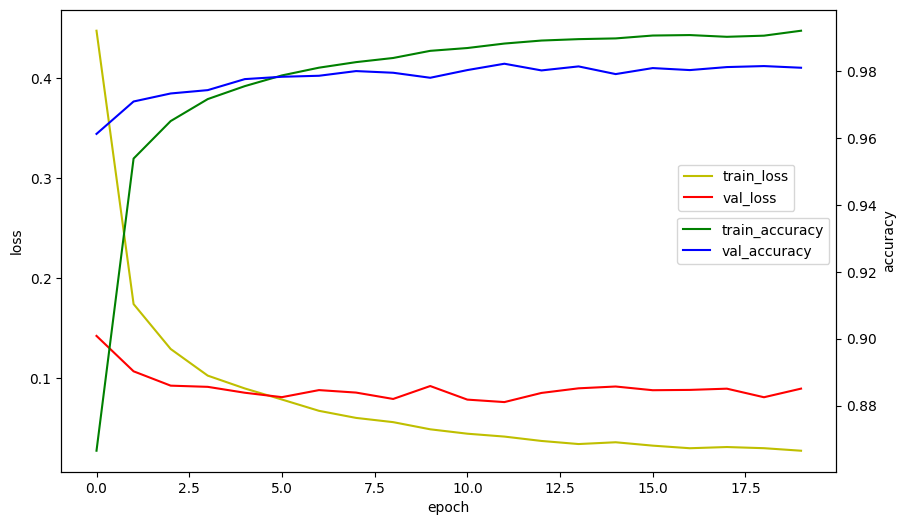

In [23]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(bbox_to_anchor=(0.955,0.68))
acc_ax.legend(loc= 'center right')
plt.show()

In [25]:
# 모델 평가하기
loss, acc = model.evaluate(test_X,test_Y, verbose=0)
acc

0.9829999804496765

In [27]:
# 틀린갯수
len(test_Y)-len(test_Y)*acc

170.00019550323486

In [31]:
# 틀린 이미지만 출력하기 위해 실제값과 예측값
# 실제값들
# real = test_Y.argmax(axis=1)
# real = np.argmax(test_Y,axsi=1)
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [34]:
# 예측값
y_hat = model.predict(test_X, verbose=0).argmax(axis=1)

In [35]:
y_test.shape, y_hat.shape # 실제값과 예측값

((10000,), (10000,))

In [36]:
pd.crosstab(y_test,y_hat)

col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,969,0,0,1,1,1,2,0,3,3
1,0,1131,0,1,0,1,1,0,1,0
2,2,2,1016,1,1,0,2,3,5,0
3,1,0,2,997,0,0,0,3,4,3
4,0,0,0,1,973,0,5,2,0,1
5,2,0,0,11,2,871,2,0,3,1
6,2,3,0,1,2,2,946,0,2,0
7,2,4,9,1,1,0,0,1000,3,8
8,1,1,1,4,2,5,3,3,952,2


In [38]:
plt_row = 18
plt_col = 10
i = 0 # y_hat과  y_test를 액세스할 index:0 ~ 9999
cnt = 0 # 이미지 출력횟수 : 1 ~ 120
while (cnt < plt_row*plt_col) & (i<len(y_test)):
    if(y_test[i] == y_hat[i]):
        i += 1
        continue
    title = f'r:{y_test[i]}/p:{y_hat[i]}'
    print(title, end='\t')
    i += 1
    cnt +=1

r:4/p:6	r:2/p:7	r:2/p:6	r:6/p:0	r:8/p:0	r:8/p:2	r:1/p:8	r:2/p:6	r:7/p:3	r:5/p:8	r:9/p:7	r:5/p:4	r:6/p:5	r:7/p:2	r:6/p:8	r:4/p:6	r:7/p:8	r:6/p:1	r:9/p:4	r:7/p:2	r:9/p:6	r:4/p:9	r:9/p:5	r:7/p:1	r:8/p:3	r:7/p:9	r:5/p:3	r:9/p:0	r:8/p:6	r:7/p:0	r:7/p:9	r:8/p:7	r:4/p:6	r:9/p:8	r:3/p:7	r:2/p:8	r:9/p:4	r:6/p:5	r:0/p:9	r:7/p:2	r:7/p:9	r:0/p:4	r:5/p:3	r:8/p:1	r:2/p:0	r:3/p:7	r:6/p:1	r:9/p:1	r:3/p:9	r:5/p:3	r:5/p:8	r:9/p:1	r:9/p:4	r:2/p:1	r:2/p:4	r:5/p:3	r:7/p:4	r:9/p:0	r:6/p:1	r:9/p:4	r:9/p:0	r:5/p:3	r:9/p:4	r:9/p:4	r:4/p:7	r:3/p:2	r:9/p:5	r:9/p:1	r:5/p:3	r:5/p:9	r:7/p:9	r:0/p:9	r:8/p:9	r:6/p:0	r:7/p:8	r:7/p:9	r:3/p:7	r:9/p:1	r:6/p:4	r:5/p:0	r:8/p:5	r:7/p:1	r:9/p:3	r:5/p:4	r:7/p:2	r:5/p:8	r:4/p:6	r:7/p:8	r:2/p:3	r:0/p:6	r:9/p:4	r:5/p:3	r:1/p:3	r:4/p:6	r:7/p:1	r:9/p:4	r:7/p:1	r:0/p:8	r:8/p:3	r:2/p:7	r:7/p:9	r:9/p:7	r:2/p:8	r:5/p:3	r:2/p:8	r:9/p:5	r:5/p:3	r:9/p:4	r:9/p:4	r:9/p:4	r:8/p:7	r:9/p:1	r:8/p:4	r:8/p:3	r:8/p:3	r:9/p:4	r:8/p:6	r:0/p:8	r:7/p:9	r:8/p:5	r:1/p:6	r:7/p:9	r:1/p:5	r:4/p:3	r:7/p:0	

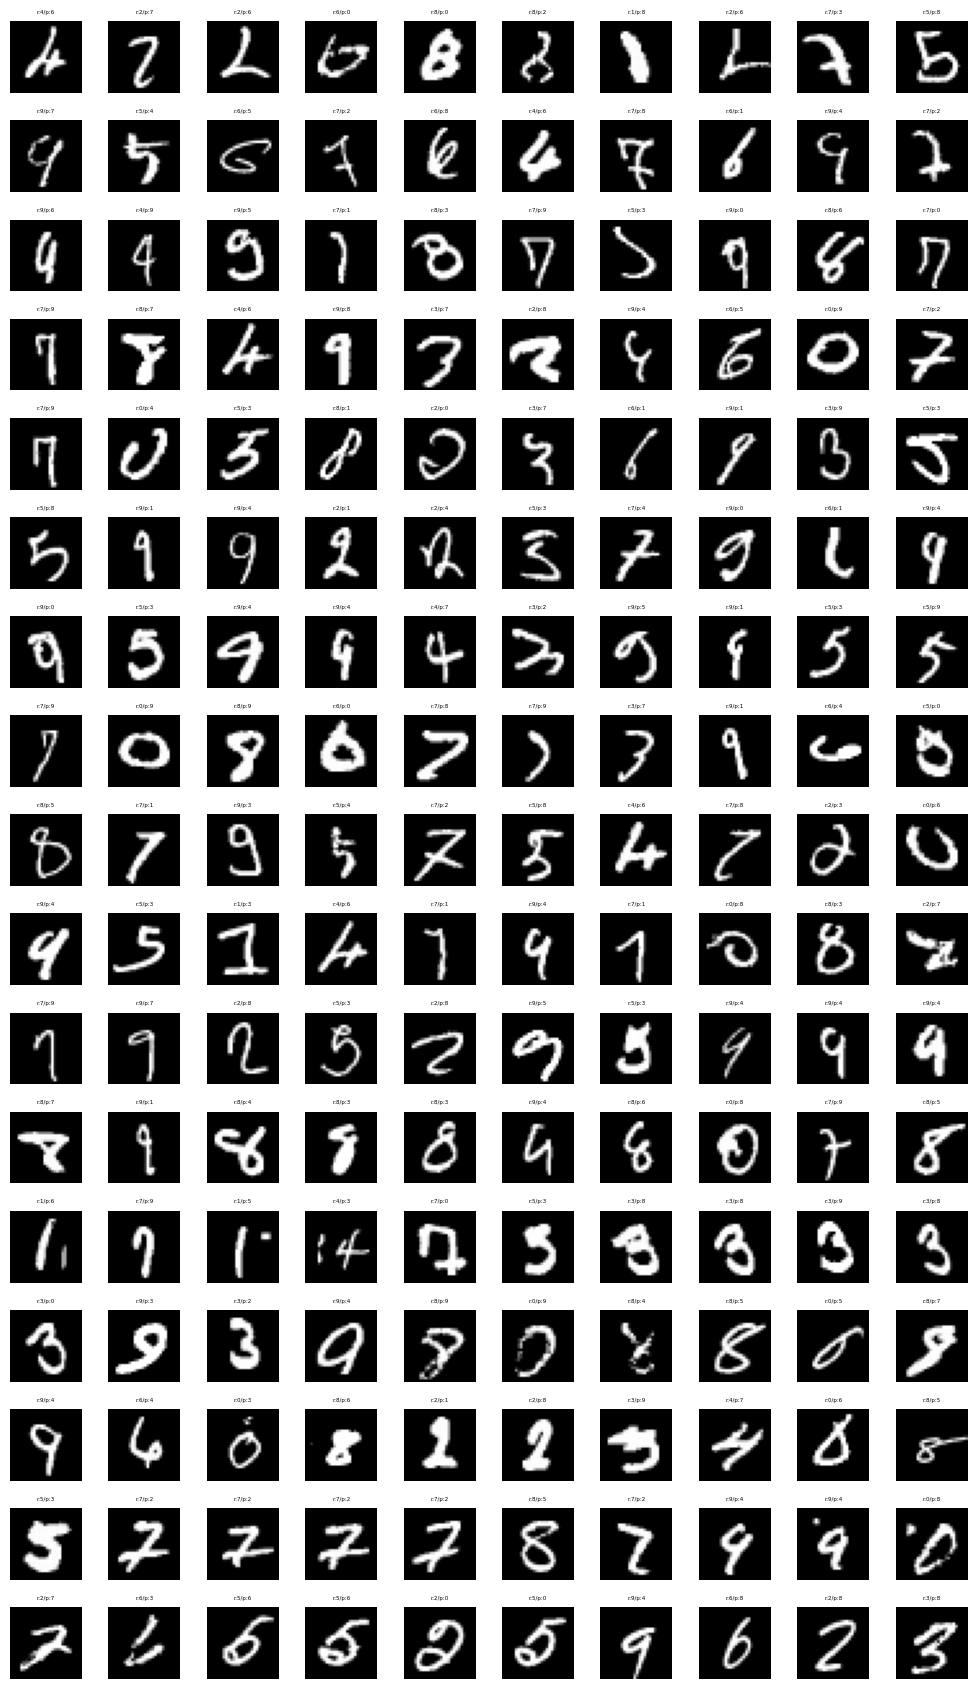

In [45]:
plt_row = 17
plt_col = 10

plt.rcParams['figure.figsize'] = (plt_col,plt_row)
fig, axarr = plt.subplots(nrows=plt_row, ncols=plt_col)

i = 0 # 출력할 이미지의 index
cnt=0 # 이미지 출력횟수 :1~120

while (cnt < plt_row*plt_col) & (i<len(y_test)):
    if(y_test[i] == y_hat[i]):
        i += 1
        continue
    title = f'r:{y_test[i]}/p:{y_hat[i]}'
    ax = axarr[cnt//plt_col, cnt%plt_col]
    ax.imshow(X_test[i], cmap ='gray')
    ax.axis('off')
    ax.set_title(title,fontsize=4)
    i += 1
    cnt +=1
plt.tight_layout()

# 2. CNN
- 컨볼루션 layer -> pooling -> 컨볼루션 layer -> pooling -> Flatten -> DNN

In [54]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 훈련 셋과 테스트 셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.layers import LeakyReLU, ELU, ReLU

from sklearn.metrics import recall_score, precision_score, accuracy_score, f1_score, confusion_matrix

#CNN
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [50]:
width = 28; height = 28
model = Sequential([
    Conv2D(filters=32, # 필터수
          kernel_size = 3, # 필터 사이즈 3*3
          padding = 'same', # zero padding / padding='volid' 기본값
          input_shape=(width,height,1), # 흑백 1채널, 칼라 3채널, 투명도까지 4채널
          activation='relu'
          ), # 28*28 1채널이미지를 32개 필터로 특성맵 추출 => 28*28*32
    MaxPool2D(pool_size=(2,2)), # 가로 2배, 세로 2배 전체 4배 줄어듦
    Dropout(0.1),
    Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Dropout(0.25),
    Flatten(),
    Dense(units=128, activation='relu'),
    Dropout(0.4),
    Dense(units=10, activation='softmax')
])
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 32)       0         
 2D)                                                             
                                                                 
 dropout_6 (Dropout)         (None, 14, 14, 32)        0         
                                                                 
 conv2d_4 (Conv2D)           (None, 12, 12, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 6, 6, 64)         0         
 2D)                                                             
                                                                 
 dropout_7 (Dropout)         (None, 6, 6, 64)         

In [55]:
%%time
# 1. 데이터 생성 및 전처리
(X_train, y_train), (X_test,y_test) = mnist.load_data()

X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.astype('float32')/255.0
val_X = X_val.astype('float32')/255.0
test_X = X_test.astype('float32')/255.0

train_Y = to_categorical(y_train)
val_Y = to_categorical(y_val)
test_Y = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape

# 2. 모델 생성
width = 28; height = 28
model = Sequential()
model.add(Conv2D(filters=32, # 필터수
          kernel_size = 3, # 필터 사이즈 3*3
          padding = 'same', # zero padding / padding='volid' 기본값
          input_shape=(width,height,1), # 흑백 1채널, 칼라 3채널, 투명도까지 4채널
          activation='relu'
          ))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.1))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(units=10, activation='softmax'))

# 3. 학습과정 설정
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
# 4. 학습하기
early_stopping=EarlyStopping(patience=10)
checkpoint = ModelCheckpoint(
    filepath='mnist-{epoch:02d}-loss{val_loss:.4f}-val{val_accuracy:.4f}.h5',
    monitor='val_accuracy',
    save_best_only= True,
    mode = 'max',
    verbose=1
)
hist = model.fit(train_X, train_Y,
                epochs=50,
                batch_size=32,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[early_stopping, checkpoint])

Epoch 1/50
1561/1563 [============================>.] - ETA: 0s - loss: 0.2211 - accuracy: 0.9309
Epoch 1: val_accuracy improved from -inf to 0.98420, saving model to mnist-01-loss0.0503-val0.9842.h5
1563/1563 [==============================] - 19s 12ms/step - loss: 0.2210 - accuracy: 0.9309 - val_loss: 0.0503 - val_accuracy: 0.9842
Epoch 2/50
1563/1563 [==============================] - ETA: 0s - loss: 0.0862 - accuracy: 0.9744
Epoch 2: val_accuracy improved from 0.98420 to 0.98800, saving model to mnist-02-loss0.0414-val0.9880.h5
1563/1563 [==============================] - 19s 12ms/step - loss: 0.0862 - accuracy: 0.9744 - val_loss: 0.0414 - val_accuracy: 0.9880
Epoch 3/50
1562/1563 [============================>.] - ETA: 0s - loss: 0.0631 - accuracy: 0.9807
Epoch 3: val_accuracy improved from 0.98800 to 0.98890, saving model to mnist-03-loss0.0366-val0.9889.h5
1563/1563 [==============================] - 21s 13ms/step - loss: 0.0631 - accuracy: 0.9807 - val_loss: 0.0366 - val_accura

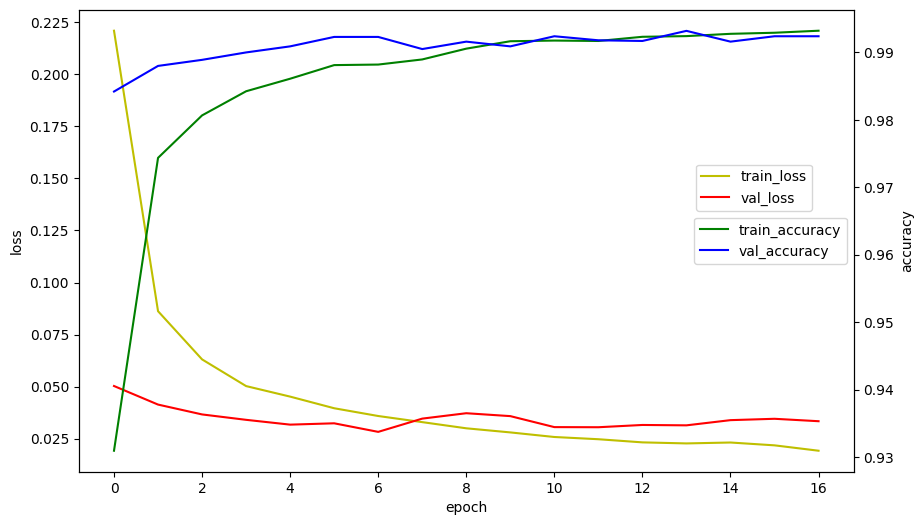

In [56]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(bbox_to_anchor=(0.955,0.68))
acc_ax.legend(loc= 'center right')
plt.show()

In [57]:
# 모델평가
loss, acc = model.evaluate(test_X,test_Y, verbose=0)
print('최종모델 :',acc, loss)

최종모델 : 0.9937999844551086 0.02291714772582054


In [61]:
model1 = load_model('mnist-14-loss0.0314-val0.9932.h5')
loss1, acc1 = model1.evaluate(test_X, test_Y, verbose=0)
print('model1 :', acc1, loss1)

model1 : 0.9934999942779541 0.022095413878560066


In [62]:
model2 = load_model('mnist-11-loss0.0305-val0.9924.h5')
loss2, acc2 = model2.evaluate(test_X, test_Y, verbose=0)
print('model2 :', acc2, loss2)

model2 : 0.9922999739646912 0.02245367132127285


In [66]:
# 성능평가(성능평가지표 = 교차표, 혼동행렬, add, recall, precision, f1)를 위해 실제값, 예측값
# 실제값 y_test
# 예측값
y_hat=np.argmax(model.predict(test_X),axis=1)

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [65]:
# 교차표
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1,2,3,4,5,6,7,8,9
실제값,,,,,,,,,,
0,978,0,0,0,0,0,0,1,1,0
1,0,1132,0,1,0,0,0,2,0,0
2,1,0,1026,0,0,0,0,5,0,0
3,0,0,0,1008,0,1,0,0,1,0
4,0,0,0,0,978,0,0,0,0,4
5,1,0,0,6,0,883,1,1,0,0
6,4,1,0,0,1,2,949,0,1,0
7,0,2,1,0,0,0,0,1024,0,1
8,3,1,1,1,0,1,0,0,966,1


In [73]:
print('accuracy :', accuracy_score(y_test,y_hat)*100, '%')
# 다중분류의 타겟변수의 균형이 비슷하면 'macro' / 균형이 안 잡힌 데이터면 'weighted'
print('recall :', recall_score(y_test,y_hat, average='weighted')*100, '%')
print('presiion :', precision_score(y_test,y_hat, average= 'weighted')*100, '%')
print('f1_score :', f1_score(y_test,y_hat,average='weighted')*100, '%')

accuracy : 99.38 %
recall : 99.38 %
presiion : 99.38158868587709 %
f1_score : 99.37988973261923 %


In [74]:
# 틀린갯수
len(y_test) - len(y_test)*acc

62.000155448913574

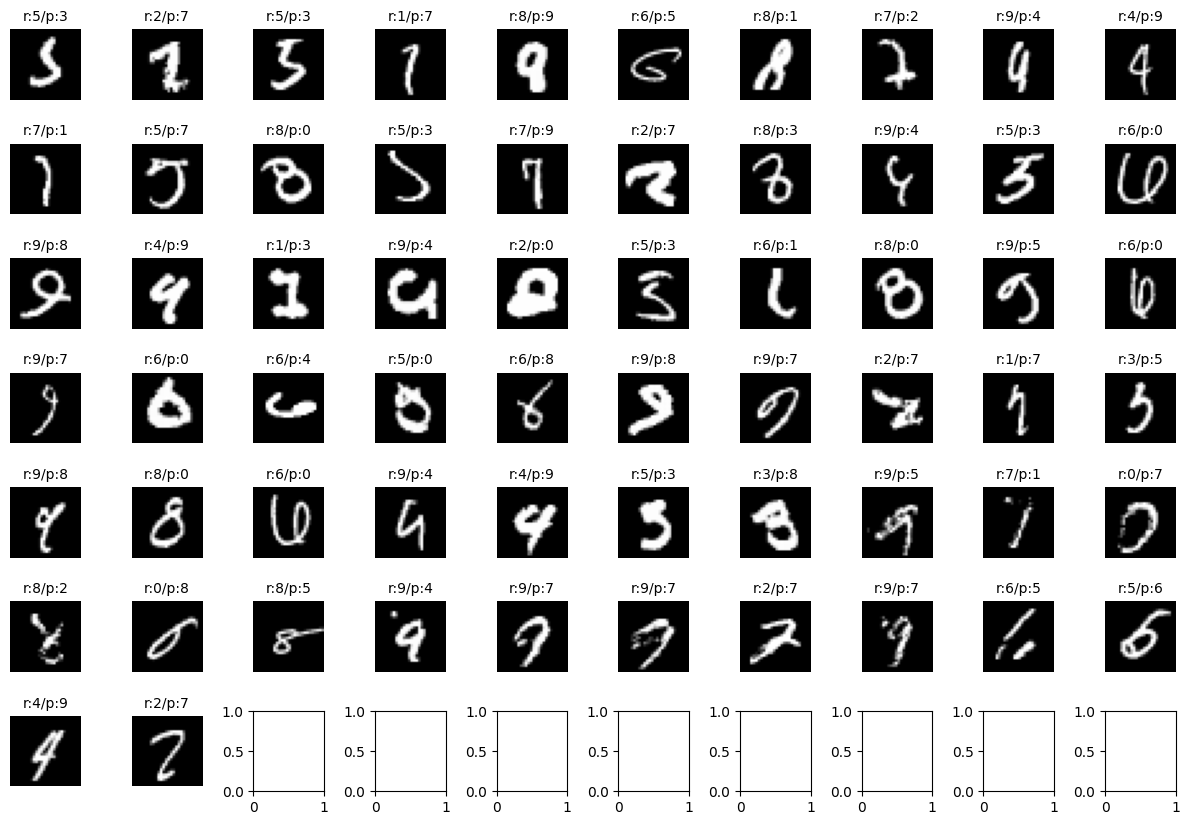

In [77]:
plt_row = 7
plt_col = 10

plt.rcParams['figure.figsize'] = (plt_col*1.2,plt_row*1.2)
fig, axarr = plt.subplots(nrows=plt_row, ncols=plt_col)

i = 0 # 출력할 이미지의 index
cnt=0 # 이미지 출력횟수 :1~120

while (cnt < plt_row*plt_col) & (i<len(y_test)):
    if(y_test[i] == y_hat[i]):
        i += 1
        continue
    title = f'r:{y_test[i]}/p:{y_hat[i]}'
    ax = axarr[cnt//plt_col, cnt%plt_col]
    ax.imshow(X_test[i], cmap ='gray')
    ax.axis('off')
    ax.set_title(title,fontsize=10)
    i += 1
    cnt +=1
plt.tight_layout()